In [1]:
import numpy as np
import pandas as pd
import os
import glob
import re
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

In [2]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")


dfDescr = pd.read_csv(os.path.join(DATA_PATH, "train_series_descriptions.csv"))
uniqueSeriesDescr = np.array(['Sagittal T2/STIR', 'Sagittal T1', 'Axial T2'])
dfDescr.set_index("study_id", inplace=True)
uniqueStudIds = dfDescr.index.unique()

dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))

In [3]:
dfDescr.head()

,series_id,series_description
study_id,,
4003253,702807833,Sagittal T2/STIR
4003253,1054713880,Sagittal T1
4003253,2448190387,Axial T2
4646740,3201256954,Axial T2
4646740,3486248476,Sagittal T1


In [4]:
allFiles = []

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images")):
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

len(allFiles)

147218

In [5]:
eps=10**(-12)

dicom = pydicom.read_file(allFiles[0])
data = pydicom.pixel_data_handlers.util.apply_modality_lut(dicom.pixel_array, dicom)
data = pydicom.pixel_data_handlers.util.apply_windowing(data, dicom)
# data = dicom.pixel_array
if dicom.PhotometricInterpretation == "MONOCHROME1":
    data = np.amax(data) - data
    
w, h = data.shape[0], data.shape[1]

#Center crop
if w>h:
    diff = w-h
    data = data[diff//2:diff//2+h, :]
if h>w:
    diff = h-w
    data = data[:, diff//2:diff//2+w]

data = data - np.min(data)
data = data * 1.0/(np.max(data)+eps)

w, h = data.shape[0], data.shape[1]

dicom

Dataset.file_meta -------------------------------
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Enhanced MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 100206310.1.1
(0002, 0010) Transfer Syntax UID                 UI: RLE Lossless
(0002, 0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002, 0013) Implementation Version Name         SH: 'PYDICOM 2.4.2'
-------------------------------------------------
(0008, 0018) SOP Instance UID                    UI: 100206310.1.1
(0008, 0023) Content Date                        DA: '20240503'
(0008, 0033) Content Time                        TM: '223743.757829'
(0008, 103e) Series Description                  LO: 'T2'
(0010, 0020) Patient ID                          LO: '100206310'
(0018, 0050) Slice Thickness                     DS: '3.5'
(0018, 0088) Spacing Between Slices              DS: '3.5'
(0018, 5100) Patient Position             

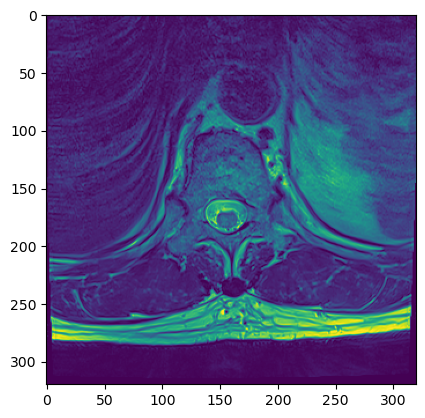

In [6]:
plt.imshow(data)

In [7]:
from enum import Enum
from DicomDataset import *


In [8]:

allData = {}

for studyId in uniqueStudIds:
    seriesIds = dfDescr.loc[studyId]["series_id"].to_numpy()
    seriesDescriptions = dfDescr.loc[studyId]["series_description"].to_numpy()
    # print(seriesDescriptions)
    scanMapping = []
    for seriesIndex,serId in enumerate(seriesIds):
        seriesDescr = seriesDescriptions[seriesIndex]
        if "Sagittal" in seriesDescr:
            orient = OrientationType.Sagittal
        elif "Axial" in seriesDescr or "Transversal" in seriesDescr:
            orient = OrientationType.Axial
        elif "Frontal" in seriesDescr:
            orient = OrientationType.Frontal
        else:
            orient = OrientationType.Unknown
        folder = os.path.join(DATA_PATH, f"train_images/{studyId}/{serId}")
        scanMapping.append((orient, folder))

    test = PatientData(scanMapping)

    break

[-3.0820034, -76.65281, -282.85712]
[-0.0011862646, 0.9999993, 5.02E-12, 0.0069542686, 8.249613E-6, -0.9999758]
[0.46875, 0.46875]
[  -2.10405938  -76.6516499  -423.47871688]
[-3.0820034, -76.65281, -282.85712]
[-0.0011862646, 0.9999993, 5.02E-12, 0.0069542686, 8.249613E-6, -0.9999758]
[0.46875, 0.46875]
[  -1.77807804  -76.6512632  -470.3525825 ]
[-3.0820034, -76.65281, -282.85712]
[-0.0011862646, 0.9999993, 5.02E-12, 0.0069542686, 8.249613E-6, -0.9999758]
[0.46875, 0.46875]
[  -1.4520967   -76.6508765  -517.22644812]
[-3.0820034, -76.65281, -282.85712]
[-0.0011862646, 0.9999993, 5.02E-12, 0.0069542686, 8.249613E-6, -0.9999758]
[0.46875, 0.46875]
[  -1.12611536  -76.6504898  -564.10031375]


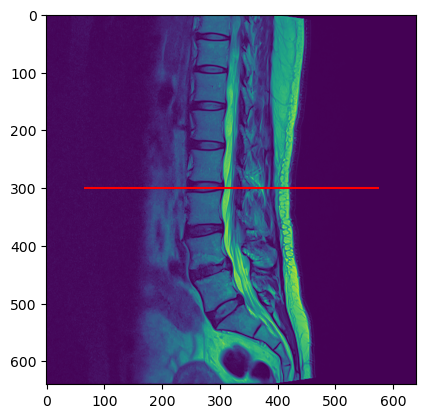

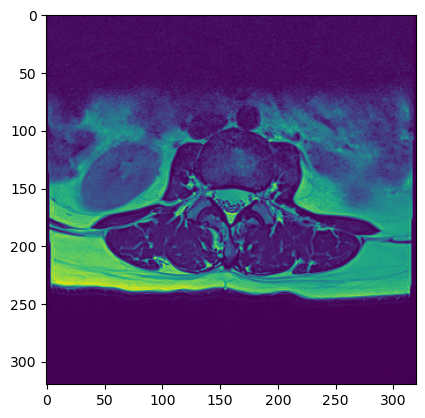

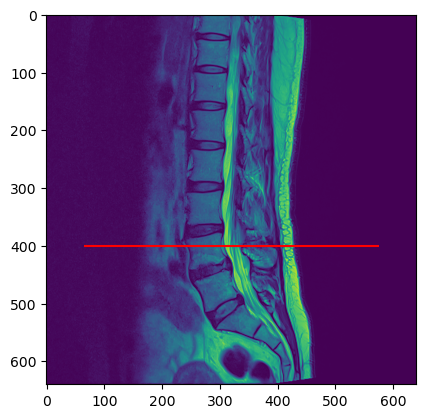

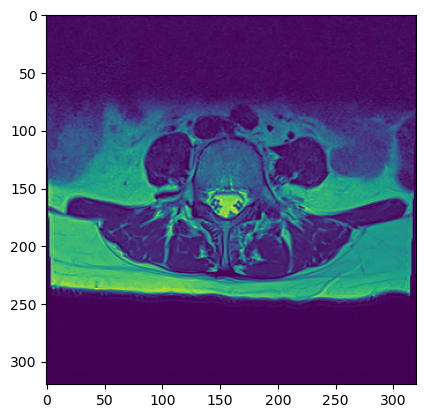

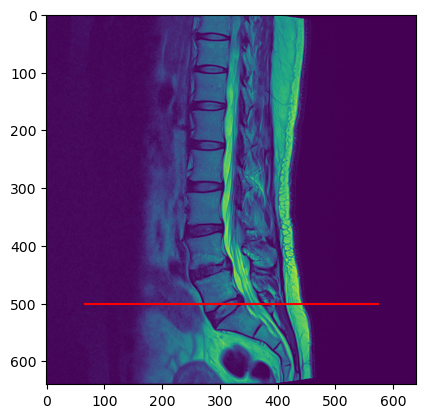

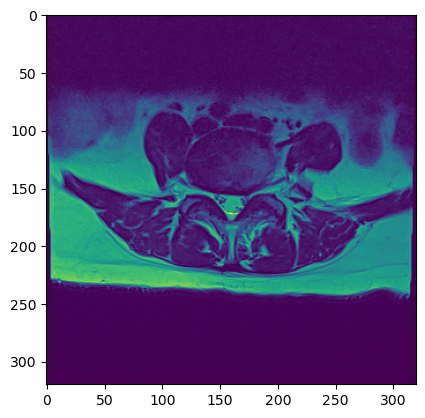

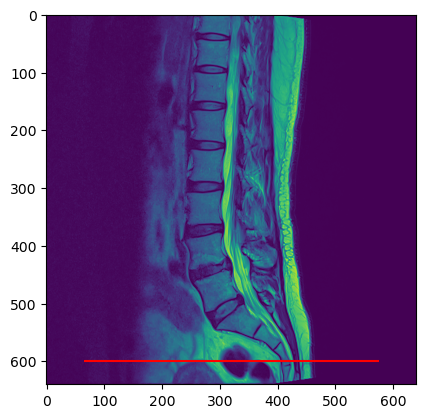

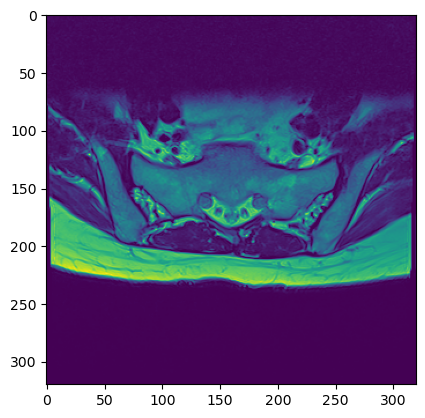

In [9]:

for yValue in [300,400,500,600]:
    test.scans[0].slices[6].plot([yValue])
    print(test.scans[0].slices[6].position)
    print(test.scans[0].slices[6].orientation)
    print(test.scans[0].slices[6].pixelSpacing)
    worldPos = test.scans[0].slices[6].getWorldPosition(0,yValue)
    print(worldPos)

    posInSagSlice = worldPos
    axScans = test.getAxialScans()[0]
    test.getClosestSliceInScanDirection(axScans, posInSagSlice, Direction.Z, 3.0).plot()

[  -2.10405938  -76.6516499  -423.47871688]
[  -1.28910603  -76.65068315 -540.66338094]


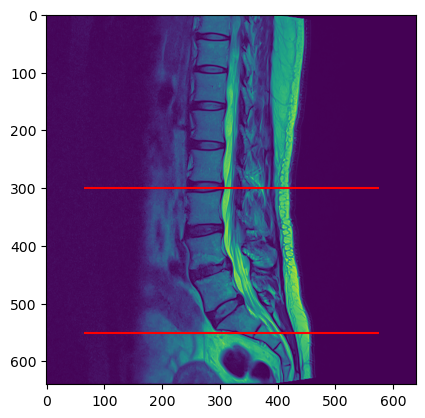

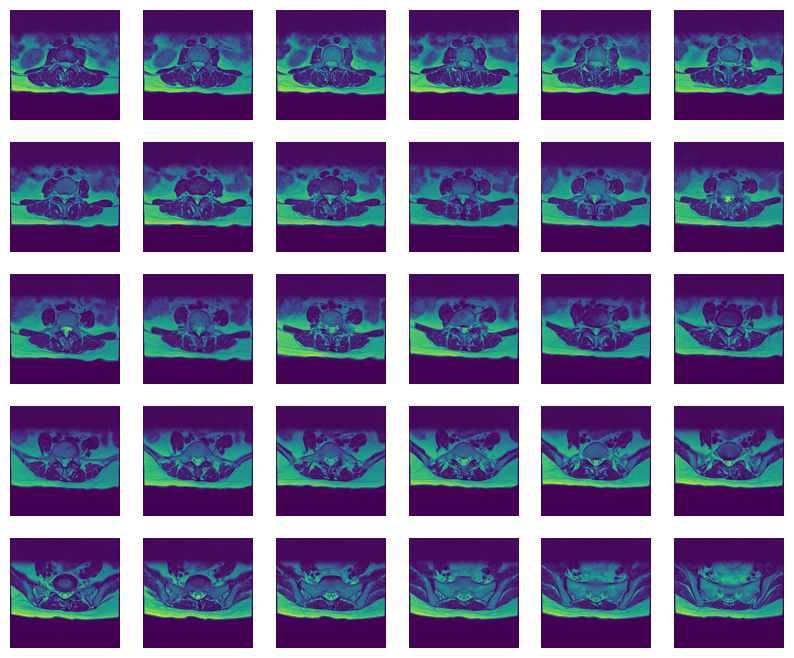

In [10]:
startXPos=300
endXPos=550
test.scans[0].slices[6].plot([startXPos,endXPos])
worldPosStart = test.scans[0].slices[6].getWorldPosition(0,startXPos)
worldPosEnd = test.scans[0].slices[6].getWorldPosition(0,endXPos)
print(worldPosStart)
print(worldPosEnd)

axScan = test.getAxialScans()[0]
foundSlices = test.getSlicesInRangeDirection(axScan, worldPosEnd, worldPosStart, Direction.Z)
plt.figure(figsize=(10,10))
numImages = int(np.ceil(np.sqrt(len(foundSlices))))
for i,s in enumerate(foundSlices):
    plt.subplot(numImages,numImages,i+1)
    plt.imshow(s.data)
    plt.axis("off")

### Position

The x, y, and z coordinates of the upper left hand corner (center of the first voxel transmitted) of the image, in mm

### Orientation

This means that the dicom world (or patient) coordinate system is LPS:

X is Right to Left (RL)
Y is Anterior to Posterior (AP)
Z is Inferior to Superior (IS)

The Image Orientation (Patient) dicom tag is (0020,0037), and is defined as 6 elements: "Ax, Ay, Az, Bx, By, Bz".

When described as a 3x3 rotation matrix R, it's equivalent to:


$$
\left(\begin{array}{cc} 
A_x & B_x & 0\\
A_y & B_y & 0\\
A_z & B_z & 0\\
\end{array}\right)
$$ 

### Pixel Spacing

Physical distance in the patient between the center of each pixel, specified by a numeric pair - adjacent row spacing (delimiter) adjacent column spacing in mm.

-----

## Data Extraction Process

1. For all patients create PatientData
1. Get all sagittal scans
1. Process every slice with the vertebrae detector
1. For every level L
    1. Get all patches from bounding boxes @ level L (extend the boxes to get the spinal canal and foramina!)
    1. Use a random slice where all levels can be seen to extract the axial slices @ level L. Also center crop them.

--> For every patient the data consists of separate data for every level

```json
{
    "L1/L2":
        {"sagittalPatches": [...], "axialSlices":[...]},
    "L2/L3":
        {"sagittalPatches": [...], "axialSlices":[...]},
    "L3/L4":
        ...
}

```